In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
)
from sklearn.ensemble import VotingClassifier
from sklearn.utils import resample

In [35]:
# Load the expression data
df = pd.read_csv("/Users/matthewng/Bioinformatics Spring 2025/ML_input_all_volcano_genes.csv", index_col=0)
X = df.drop(columns=["label"])
y = df["label"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

In [36]:
# Count how many 0s and 1s are in the labels
label_counts = pd.Series(y).value_counts()
print("Label counts:\n", label_counts)

Label counts:
 label
1    75
0    14
Name: count, dtype: int64


/Users/matthewng/PycharmProjects/HTP_Project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/HTP_Project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/HTP_Project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/HTP_Project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/HTP_Project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma

Training Accuracy: 0.9859
Testing Accuracy: 0.8889
Cross-validation Accuracy: 0.8038 ± 0.1021
Training Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      0.98      0.99        60

    accuracy                           0.99        71
   macro avg       0.96      0.99      0.97        71
weighted avg       0.99      0.99      0.99        71

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       1.00      0.87      0.93        15

    accuracy                           0.89        18
   macro avg       0.80      0.93      0.84        18
weighted avg       0.93      0.89      0.90        18



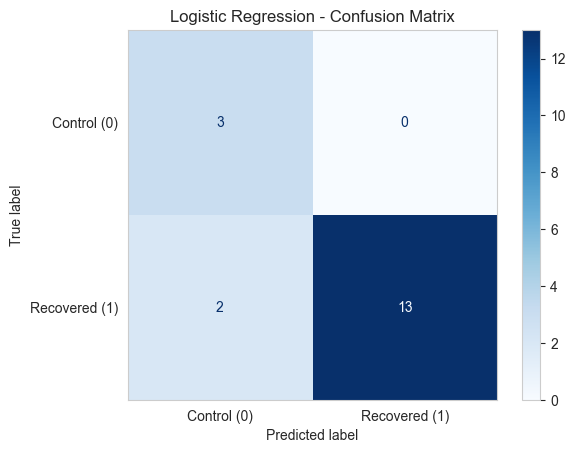

In [37]:
# Logistic Regression

lr_model = LogisticRegression(C=10, penalty='l1', solver='saga', class_weight='balanced')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred_lr)
report = classification_report(y_test, y_pred_lr)

train_accuracy_lr = lr_model.score(X_train_scaled, y_train)
test_accuracy_lr = lr_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy_lr:.4f}")
print(f"Testing Accuracy: {test_accuracy_lr:.4f}")

train_pred_lr = lr_model.predict(X_train_scaled)
test_pred_lr = lr_model.predict(X_test_scaled)

cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("Training Classification Report:")
print(classification_report(y_train, train_pred_lr))

print("Testing Classification Report:")
print(classification_report(y_test, test_pred_lr))

lr_conf_matrix = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=lr_conf_matrix,
                              display_labels=["Control (0)", "Recovered (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression - Confusion Matrix")
plt.grid(False)
plt.show()

In [38]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    scoring='accuracy',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
print("Best parameters:", grid_search.best_params_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


Training Accuracy: 1.0000
Testing Accuracy: 0.8889
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        60

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.93      0.93      0.93        15

    accuracy                           0.89        18
   macro avg       0.80      0.80      0.80        18
weighted avg       0.89      0.89      0.89        18

Cross-validation Accuracy: 0.8590 ± 0.0453


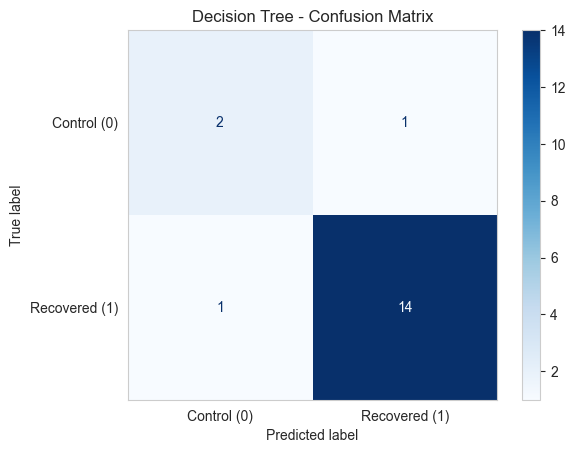

In [39]:
# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3, min_samples_split=2, min_samples_leaf=1, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
dt_model.fit(X_train_scaled, y_train)


# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the Decision Tree model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt)

train_accuracy_dt = dt_model.score(X_train_scaled, y_train)
test_accuracy_dt = dt_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy_dt:.4f}")
print(f"Testing Accuracy: {test_accuracy_dt:.4f}")

train_pred_dt = dt_model.predict(X_train_scaled)
test_pred_dt = dt_model.predict(X_test_scaled)

print("Training Classification Report:")
print(classification_report(y_train, train_pred_dt))

print("Testing Classification Report:")
print(classification_report(y_test, test_pred_dt))

cv_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

dt_conf_matrix = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=dt_conf_matrix,
                              display_labels=["Control (0)", "Recovered (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Decision Tree - Confusion Matrix")
plt.grid(False)
plt.show()


Training Accuracy: 1.0000
Testing Accuracy: 0.8889
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        60

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.93      0.93      0.93        15

    accuracy                           0.89        18
   macro avg       0.80      0.80      0.80        18
weighted avg       0.89      0.89      0.89        18



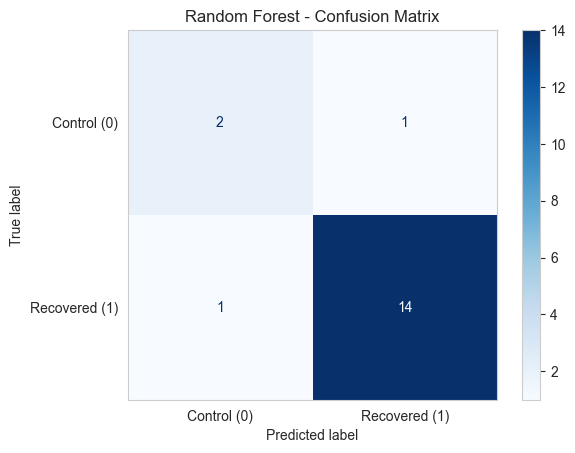

In [40]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, min_samples_split=10, bootstrap=False, random_state=42, class_weight='balanced')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
rf_model.fit(X_train_scaled, y_train)


# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

train_accuracy_rf = rf_model.score(X_train_scaled, y_train)
test_accuracy_rf = rf_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy_rf:.4f}")
print(f"Testing Accuracy: {test_accuracy_rf:.4f}")

train_pred_rf = rf_model.predict(X_train_scaled)
test_pred_rf = rf_model.predict(X_test_scaled)

print("Training Classification Report:")
print(classification_report(y_train, train_pred_rf))

print("Testing Classification Report:")
print(classification_report(y_test, test_pred_rf))

rf_conf_matrix = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=rf_conf_matrix,
                              display_labels=["Control (0)", "Recovered (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest - Confusion Matrix")
plt.grid(False)
plt.show()

In [41]:
# SVM Parameter Tuning

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_param_grid = {
    'C': [0.1, 1, 10, 100],   # Regularization parameter
    'gamma': [0.01, 0.1, 1, 'scale'],  # Kernel coefficient
    'kernel': ['rbf', 'linear'],
    'class_weight': ['balanced']
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid=svm_param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

# Fit the model
svm_grid.fit(X_train_scaled, y_train)

print("Best SVM parameters:", svm_grid.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best SVM parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}


Training Accuracy: 1.0000
Testing Accuracy: 0.8889
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        60

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.93      0.93      0.93        15

    accuracy                           0.89        18
   macro avg       0.80      0.80      0.80        18
weighted avg       0.89      0.89      0.89        18



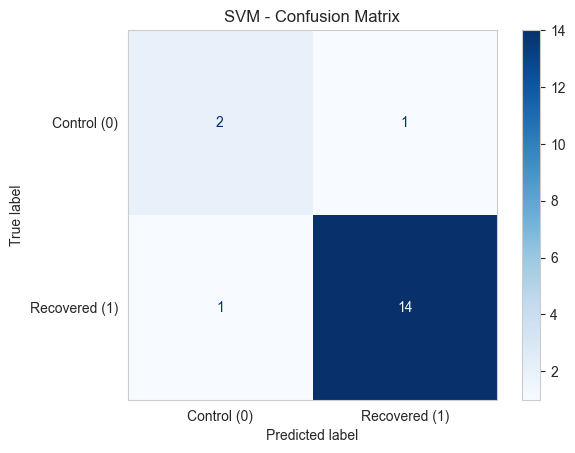

In [42]:
# SVM model

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


selector = SelectKBest(score_func=f_classif, k='all')
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)
svm_model = SVC(kernel = 'rbf', C = 1, class_weight='balanced', gamma = 0.01, random_state=42, probability=True)
svm_model.fit(X_train_selected, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_selected)
y_prob_svm = svm_model.predict_proba(X_test_selected)[:, 1]

# Evaluate the SVM Model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)

train_pred_svm = svm_model.predict(X_train_selected)
test_pred_svm = svm_model.predict(X_test_selected)

train_accuracy_svm = svm_model.score(X_train_selected, y_train)
test_accuracy_svm = svm_model.score(X_test_selected, y_test)

print(f"Training Accuracy: {train_accuracy_svm:.4f}")
print(f"Testing Accuracy: {test_accuracy_svm:.4f}")

print("Training Classification Report:")
print(classification_report(y_train, train_pred_svm))

print("Testing Classification Report:")
print(classification_report(y_test, test_pred_svm))

svm_conf_matrix = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=svm_conf_matrix,
                              display_labels=["Control (0)", "Recovered (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("SVM - Confusion Matrix")
plt.grid(False)
plt.show()

In [43]:
# KNN Parameter Tuning

# Hyperparameter tuning
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  # Number of neighbors
    'weights': ['uniform', 'distance'],  # Uniform or weighted
    'metric': ['euclidean', 'manhattan']
}

# Setup GridSearchCV
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

# Fit the model
knn_grid.fit(X_train_scaled, y_train)

# Best model
print("Best KNN parameters:", knn_grid.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best KNN parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


Training Accuracy: 0.9577
Testing Accuracy: 0.9444
Training Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        11
           1       0.98      0.97      0.97        60

    accuracy                           0.96        71
   macro avg       0.91      0.94      0.92        71
weighted avg       0.96      0.96      0.96        71

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.93      0.97        15

    accuracy                           0.94        18
   macro avg       0.88      0.97      0.91        18
weighted avg       0.96      0.94      0.95        18



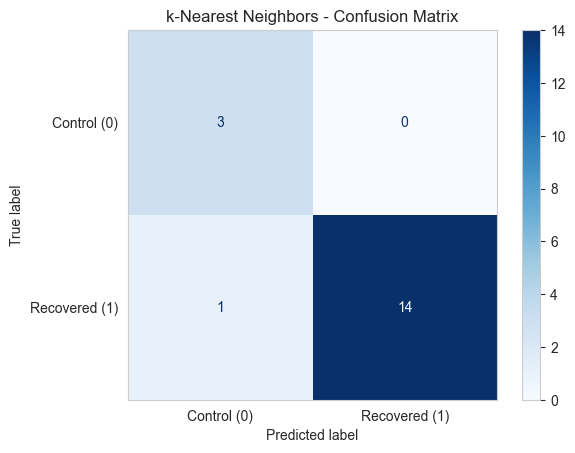

In [44]:
# KNN model

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a K-Nearest Neighbors (KNN) model
knn_model = KNeighborsClassifier(metric= 'euclidean', n_neighbors=3, weights= 'uniform')
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the KNN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)

train_pred_knn = knn_model.predict(X_train_scaled)
test_pred_knn = knn_model.predict(X_test_scaled)

train_accuracy_knn = knn_model.score(X_train_scaled, y_train)
test_accuracy_knn = knn_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy_knn:.4f}")
print(f"Testing Accuracy: {test_accuracy_knn:.4f}")

print("Training Classification Report:")
print(classification_report(y_train, train_pred_knn))

print("Testing Classification Report:")
print(classification_report(y_test, test_pred_knn))

knn_conf_matrix = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=knn_conf_matrix,
                              display_labels=["Control (0)", "Recovered (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("k-Nearest Neighbors - Confusion Matrix")
plt.grid(False)
plt.show()


In [45]:
print("\nBuilding an ensemble of top models (Logistic Regression, Random Forest, SVM)...")


log_clf = LogisticRegression(C=10, penalty='l1', solver='saga', class_weight='balanced')
dt_clf = DecisionTreeClassifier(max_depth=3, min_samples_split=2, min_samples_leaf=1, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, min_samples_split=10, bootstrap=False, random_state=42, class_weight='balanced')
knn_clf = KNeighborsClassifier(metric= 'euclidean', n_neighbors=3, weights= 'uniform')
svm_clf = SVC(kernel = 'rbf', C = 1, class_weight='balanced', gamma = 0.01, random_state=42, probability=True)

# Combining top-performing models
voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_clf),
    #    ('dt', dt_clf),
    #    ('rf', rf_clf),
    #    ('svm', svm_clf),
        ('knn', knn_clf)
                ],
    voting='soft',  # or 'hard'
  weights=[1, 1]
)
 # soft averages predicted probabilities

voting_clf.fit(X_train_scaled, y_train)
y_pred_ensemble_tuned = voting_clf.predict(X_test_scaled)

# Calculate evaluation metrics
acc = accuracy_score(y_test, y_pred_ensemble_tuned)
prec = precision_score(y_test, y_pred_ensemble_tuned)
rec = recall_score(y_test, y_pred_ensemble_tuned)
f1 = f1_score(y_test, y_pred_ensemble_tuned)

print("Ensemble (Tuned Models) Evaluation Metrics:")
print(f"Accuracy: {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print(f"F1 Score: {f1:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble_tuned))


Building an ensemble of top models (Logistic Regression, Random Forest, SVM)...
Ensemble (Tuned Models) Evaluation Metrics:
Accuracy: 0.94
Precision: 1.00
Recall: 0.93
F1 Score: 0.97

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.93      0.97        15

    accuracy                           0.94        18
   macro avg       0.88      0.97      0.91        18
weighted avg       0.96      0.94      0.95        18



/Users/matthewng/PycharmProjects/HTP_Project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


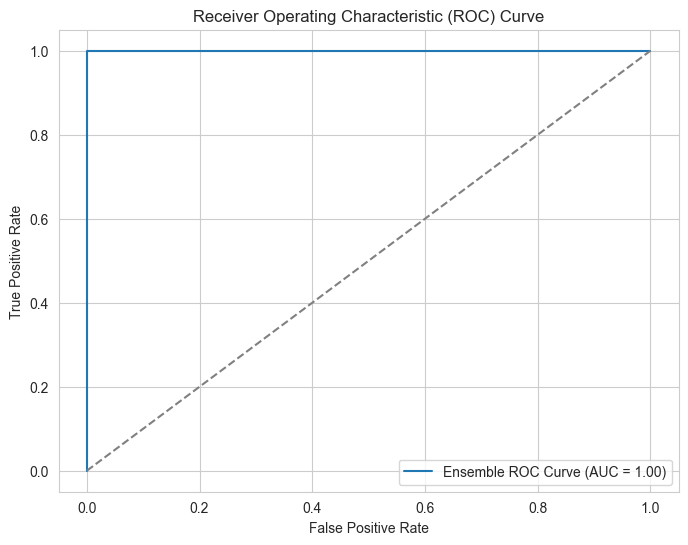

In [46]:
y_proba_ensemble = voting_clf.predict_proba(X_test_scaled)[:, 1]  # Probability for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_proba_ensemble)
auc_score = roc_auc_score(y_test, y_proba_ensemble)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Ensemble ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(True)
plt.savefig("ensemble_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

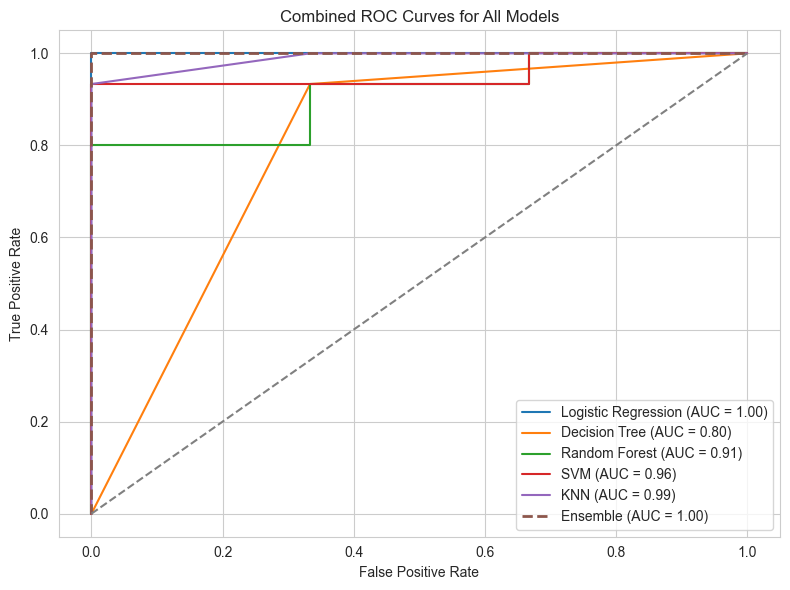

In [47]:
# Compute evaluation metrics
fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test, y_proba_ensemble)
auc_ensemble = roc_auc_score(y_test, y_proba_ensemble)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot(fpr_ensemble, tpr_ensemble, label=f'Ensemble (AUC = {auc_ensemble:.2f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title('Combined ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig("combined_roc_all_models.png", dpi=300, bbox_inches='tight')
plt.show()

Plotting Ensemble Learning Curve with Custom Colors...


/Users/matthewng/PycharmProjects/HTP_Project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/HTP_Project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/HTP_Project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/HTP_Project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/HTP_Project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma

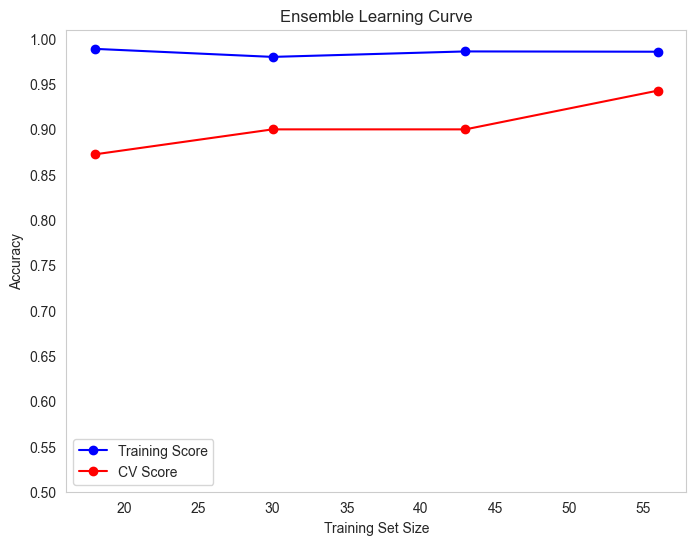

In [48]:
print("Plotting Ensemble Learning Curve with Custom Colors...")

# Ensure ensemble_tuned is defined and trained in previous cells
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    voting_clf, X_train_scaled, y_train, cv=cv, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True, random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label="Training Score")
plt.plot(train_sizes, val_mean, 'o-', color='red', label="CV Score")
plt.title("Ensemble Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.yticks([i/100 for i in range(0, 101, 5)])
plt.ylim(0.5, 1.01)
plt.legend()
plt.grid()
plt.savefig("ensemble_learning_curve.png", dpi=300, bbox_inches='tight')
plt.show()